In [19]:
!pwd
!ls /Users/markhsia/robustelli_lab/"Mutant Substitution files"/Tau5_w_sub

/Users/markhsia/robustelli_lab
aromatic_tau5_sub_pdb aromatic_tau5_sub_xtc


In [27]:
import matplotlib.pyplot as plt
import numpy as np
import mdtraj as md
import glob
import os
import pickle

xtcs = np.array(glob.glob('Mutant Substitution files/ag_sub_tau5/ag_sub_tau5_xtc/*.xtc'))
pdbs = np.array(glob.glob('Mutant Substitution files/ag_sub_tau5/ag_sub_tau5_pdb/*.pdb'))

wt_dir = "/Users/markhsia/robustelli_lab/WT ensembles"

wt_xtc_file = glob.glob(f"{wt_dir}/tau5_wt_ensemble.xtc")[0]
wt_pdb_file = glob.glob(f"{wt_dir}/tau5_wt_ensemble.pdb")[0]

In [28]:
def compute_contact_map(xtc_file, pdb_file, cutoff=1.0):
    traj = md.load(xtc_file, top=pdb_file)

    # Select C-alpha atoms
    ca_atoms = traj.topology.select("name CA")
    traj_ca = traj.atom_slice(ca_atoms)

    n_res = traj_ca.n_atoms

    # Generate all residue pairs (i < j)
    pairs = np.array([[i, j] for i in range(n_res) for j in range(i + 1, n_res)])

    # Compute distances
    distances = md.compute_distances(traj_ca, pairs)

    # Determine contacts
    contacts = distances < cutoff
    contact_prob = contacts.mean(axis=0)

    # Build symmetric contact map
    contact_map = np.zeros((n_res, n_res))
    for idx, (i, j) in enumerate(pairs):
        contact_map[i, j] = contact_prob[idx]
        contact_map[j, i] = contact_prob[idx]

    # preset diagonal to 1
    contact_map[np.diag_indices(n_res)] = 1.0

    #clip masks directly setting max/min
    counts = np.clip(contact_map, 1e-8, None)
    F = -np.log(counts)
    F -= F.min()

    return F, contact_map

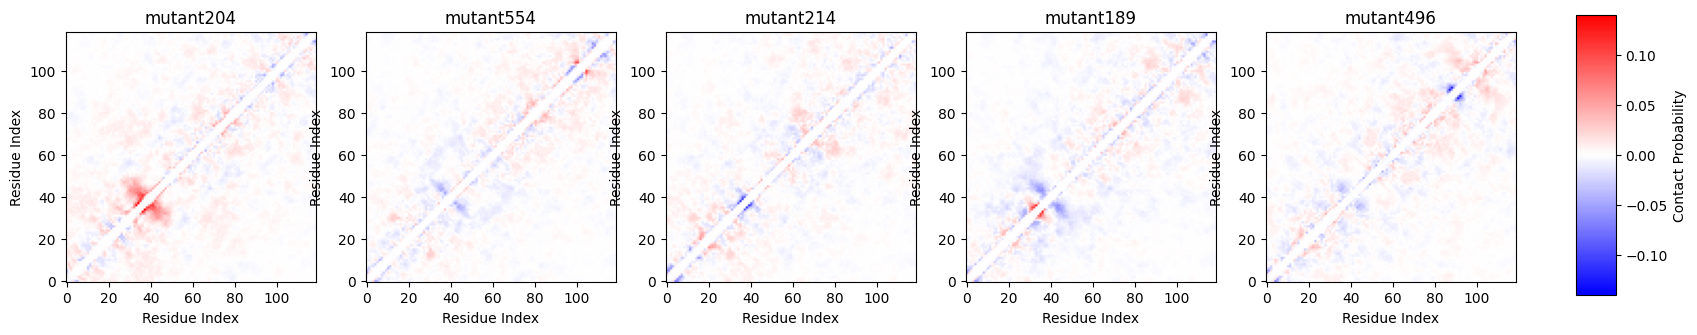

In [50]:
masked_wt_contact_map, wt_contact_map = compute_contact_map(wt_xtc_file, wt_pdb_file)

mutants = ["mutant204", "mutant554", "mutant214", "mutant189", "mutant496"]
all_diff_maps = []

for mutant in mutants:
    xtc_file = [x for x in xtcs if mutant in os.path.basename(x)][0]
    pdb_file = [p for p in pdbs if mutant in os.path.basename(p)][0]

    _, mutant_contact_map = compute_contact_map(xtc_file, pdb_file)
    diff_map = mutant_contact_map - wt_contact_map
    all_diff_maps.append(diff_map)

global_abs_max = max(np.max(np.abs(dm)) for dm in all_diff_maps)

fig, axes = plt.subplots(1, len(mutants), figsize=(4*len(mutants), 4))

if len(mutants) == 1:
    axes = [axes]

for i, mutant in enumerate(mutants):
    xtc_file = [x for x in xtcs if mutant in os.path.basename(x)][0]
    pdb_file = [p for p in pdbs if mutant in os.path.basename(p)][0]

    masked_mutant_contact_map, mutant_contact_map = compute_contact_map(xtc_file, pdb_file)
    diff_map = mutant_contact_map - wt_contact_map

    ax = axes[i]
    im = ax.imshow(diff_map, cmap="bwr", origin="lower",
                   vmin=-global_abs_max, vmax=global_abs_max)
    ax.set_title(f"{mutant}")
    ax.set_xlabel("Residue Index")
    ax.set_ylabel("Residue Index")

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Contact Probability")
plt.show()

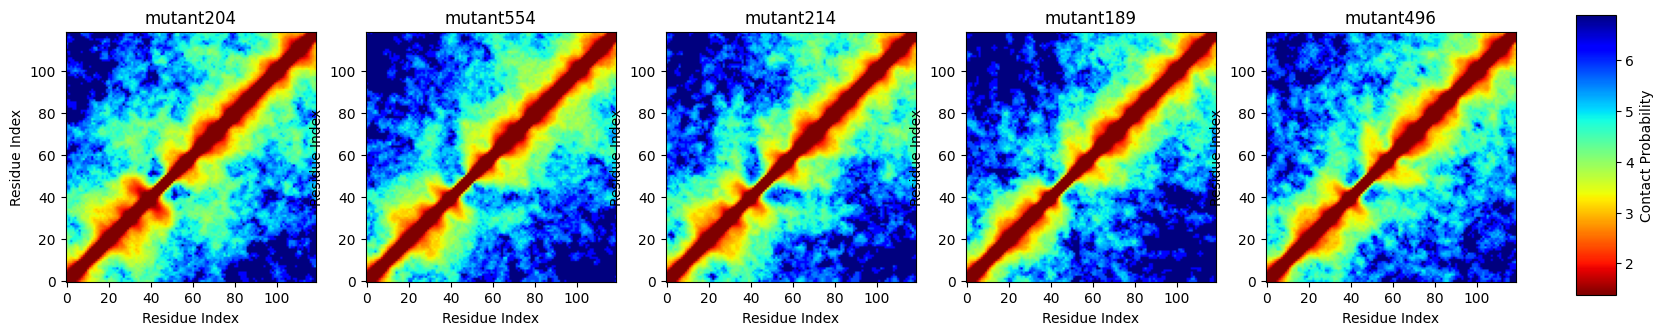

In [51]:
masked_wt_contact_map, wt_contact_map = compute_contact_map(wt_xtc_file, wt_pdb_file)

mutants = ["mutant204", "mutant554", "mutant214", "mutant189", "mutant496"]

fig, axes = plt.subplots(1, len(mutants), figsize=(4*len(mutants), 4))
if len(mutants) == 1:
    axes = [axes]

for i, mutant in enumerate(mutants):
    xtc_file = [x for x in xtcs if mutant in os.path.basename(x)][0]
    pdb_file = [p for p in pdbs if mutant in os.path.basename(p)][0]

    masked_mutant_contact_map, mutant_contact_map = compute_contact_map(xtc_file, pdb_file)
    log_diff_map = masked_mutant_contact_map - masked_wt_contact_map
    diff_map = mutant_contact_map - wt_contact_map

    ax = axes[i]
    im = ax.imshow(masked_mutant_contact_map, cmap="jet_r", origin="lower",
                   vmax=6.9, vmin=1.38)
    ax.set_title(f"{mutant}")
    ax.set_xlabel("Residue Index")
    ax.set_ylabel("Residue Index")

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Contact Probability")
plt.show()

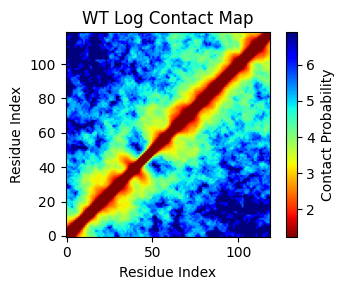

In [31]:
plt.figure(figsize=(8/2, 6/2))
plt.imshow(masked_wt_contact_map, cmap="jet_r", origin="lower", vmin=6.9, vmax=1.38)
plt.colorbar(label="Contact Probability")
plt.xlabel("Residue Index")
plt.ylabel("Residue Index")
plt.title("WT Log Contact Map")
plt.tight_layout()
plt.show()

In [ ]:
#W subs R2R3 lowest 1) RG JS 2) contact sum JS 3) r2r3 diff
#mutants = ["mutant378", "mutant454", "mutant644", "mutant17", "mutant1044"]
#mutants = ["mutant891", "mutant1062", "mutant56", "mutant1044", "mutant112"]
#mutants = ["mutant587", "mutant568", "mutant549", "mutant1044", "mutant492"]

mutants = ["mutant141", "mutant116", "mutant265", "mutant258", "mutant399"]
["mutant395", "mutant250", "mutant327", "mutant269", "mutant420"]